# Phase 1 Nutrient Analysis

### load packages, read in data, etc.

In [2]:
#load packages
library(lme4) #for linear mixed effects model
library(readr) #to read in data
library(tidyr)
library(emmeans) #for post hocs
library(esquisse) #interface for building plots
library(dplyr) #for data wrangling
library(nlme) #for linear mixed effects model
library(car) #for the Levene test
library(ggplot2) #for graphs
library(plotrix) #for standard error
library(performance) #model testing
library(lmtest) #another option than levene test for variance

In [3]:
#set contrasts
options(contrasts = c("contr.sum","contr.poly")) #could also be contr.treatment for unequal groups sum
getOption("contrasts") 

[1] "contr.sum"  "contr.poly"

In [4]:
#Read in dataset, set column types
getwd()
setwd("/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC/Oyster_Nutrient_Data/Phase1_Nutrient")

[1] "/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC"

In [7]:
#read in % data
Tissue_Nutrient_df <- read_csv("Phase1_tissuenutrient_working.csv", 
                        col_types = cols(wt_percent_N = col_number(), 
                                         wt_percent_C = col_number()))

In [8]:
#filter out data points (errors/replicates)
N_T_df <- Tissue_Nutrient_df%>%
  filter(N_exclude != "Y" | is.na(N_exclude))

C_T_df <- Tissue_Nutrient_df%>%
  filter(C_exclude != "Y" | is.na(C_exclude))

## % Nitrogen in Tissue

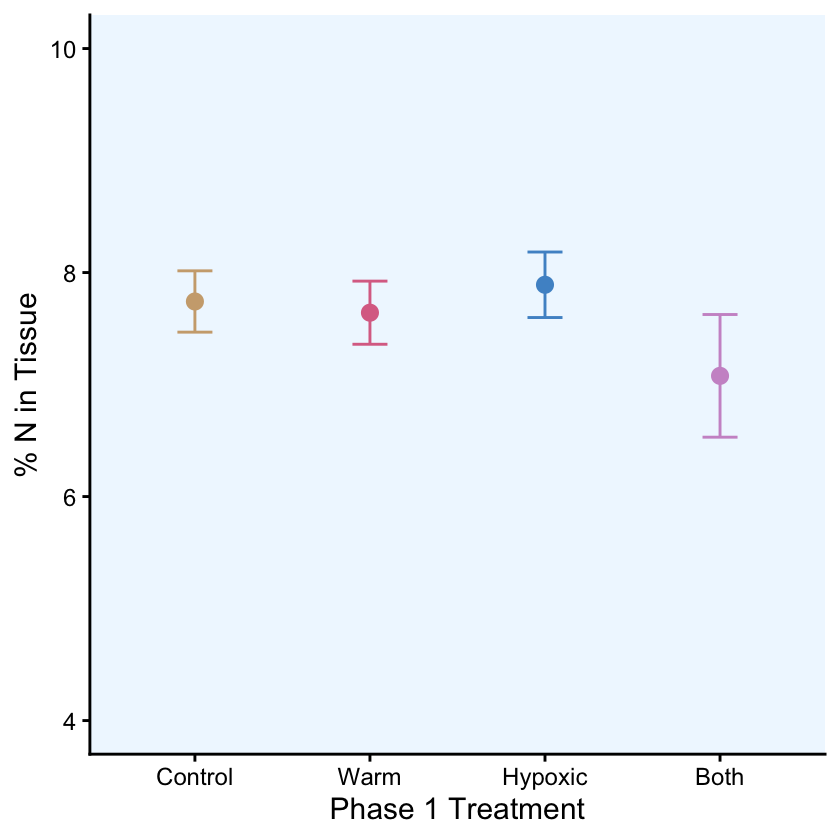

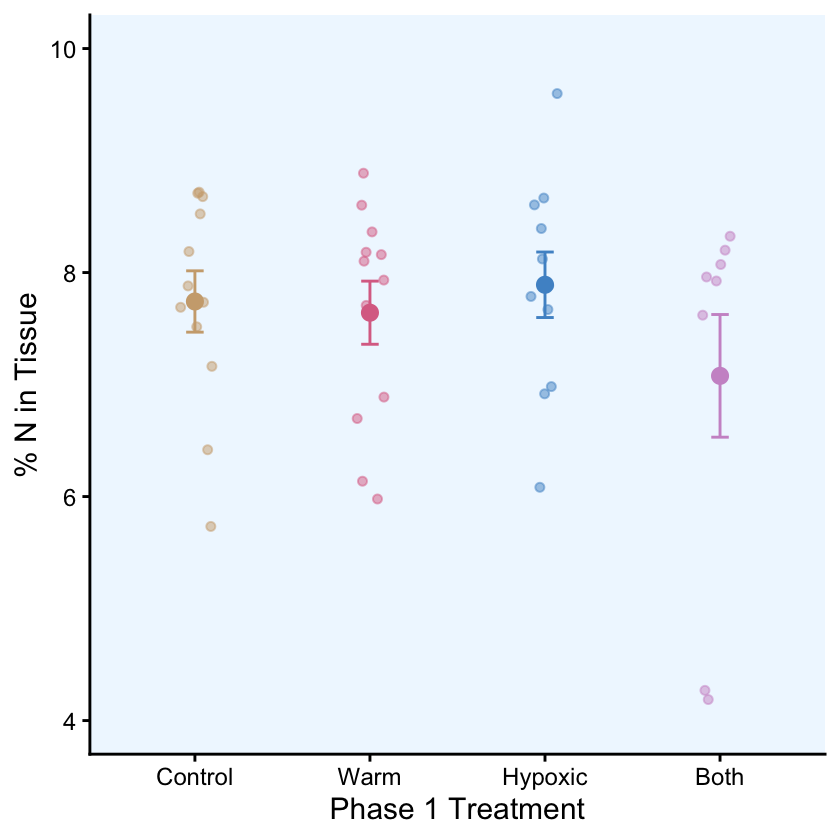

In [25]:
#summary stats
summary_stats <- N_T_df %>%
  group_by(Phase_1_treat) %>%
  summarize(
    mean_growth = mean(wt_percent_N, na.rm = TRUE),
    se_growth = std.error(wt_percent_N, na.rm = TRUE))
#reorder Phase_1_treat
summary_stats$Phase_1_treat <- factor(summary_stats$Phase_1_treat, 
                                      levels = c("Cont", "Warm","Hyp", "Both"))
#plot
ggplot(summary_stats, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light grey
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "% N in Tissue") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  ylim(4,10)+
  theme(legend.position = "none") # Remove legend
#plot with raw data
ggplot(summary_stats, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_jitter(data = N_T_df,
              aes(x = Phase_1_treat, y = wt_percent_N, color = Phase_1_treat),
              width = 0.1, alpha = 0.5, size = 2) +
  geom_point(size = 4, position = position_dodge(0.9)) +
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.1, position = position_dodge(0.9)) +
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) +
  guides(color = "none") +
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred",
                                "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "% N in Tissue") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control",
                              "Warm" = "Warm", "Both" = "Both")) +
  ylim(4, 10) +
  theme(legend.position = "none")

### Analysis

In [42]:
Nm1 <- lmer(wt_percent_N ~ Phase_1_DO*Phase_1_temp + 
              (1|Phase_1_rep_R), data = N_T_df, REML=TRUE)

aov_tab <- Anova(Nm1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1926.3720992,1,19.57171,0.0000
Phase_1_DO,0.3595182,1,19.57171,0.5557
Phase_1_temp,1.7435381,1,19.57171,0.2019
Phase_1_DO:Phase_1_temp,1.0634180,1,19.57171,0.3150


#### No significant interactions

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,3,0.3181501,0.8121661
,40,NA,NA


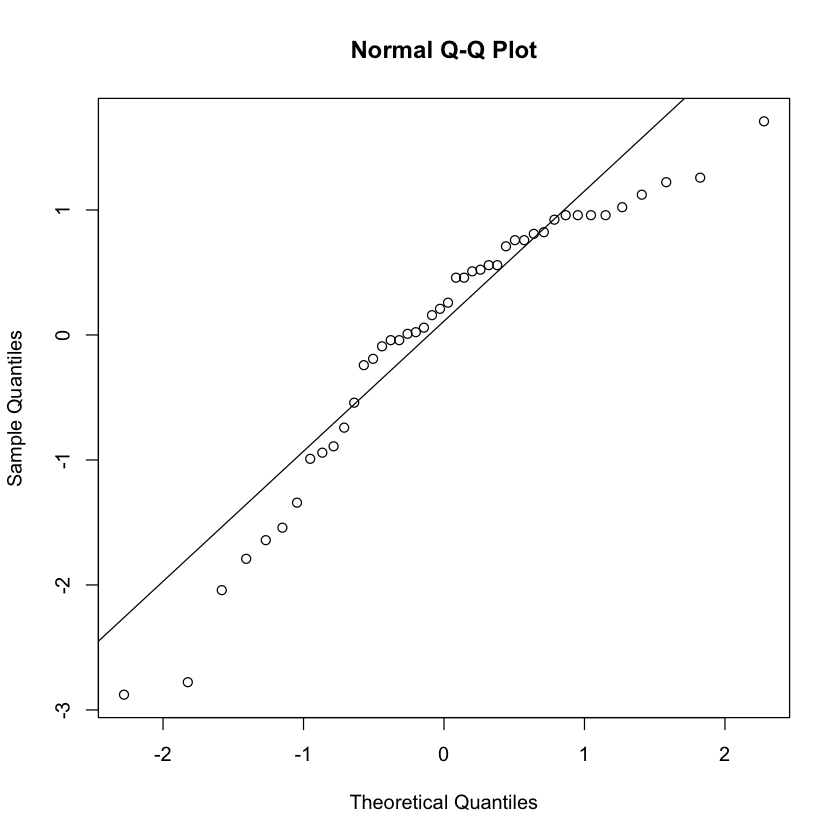

In [43]:
#diagnostics
leveneTest(wt_percent_N~Phase_1_DO*Phase_1_temp, N_T_df)
m1.e <- residuals(Nm1) 
qqnorm(m1.e)
qqline(m1.e)

## Carbon in Tissue

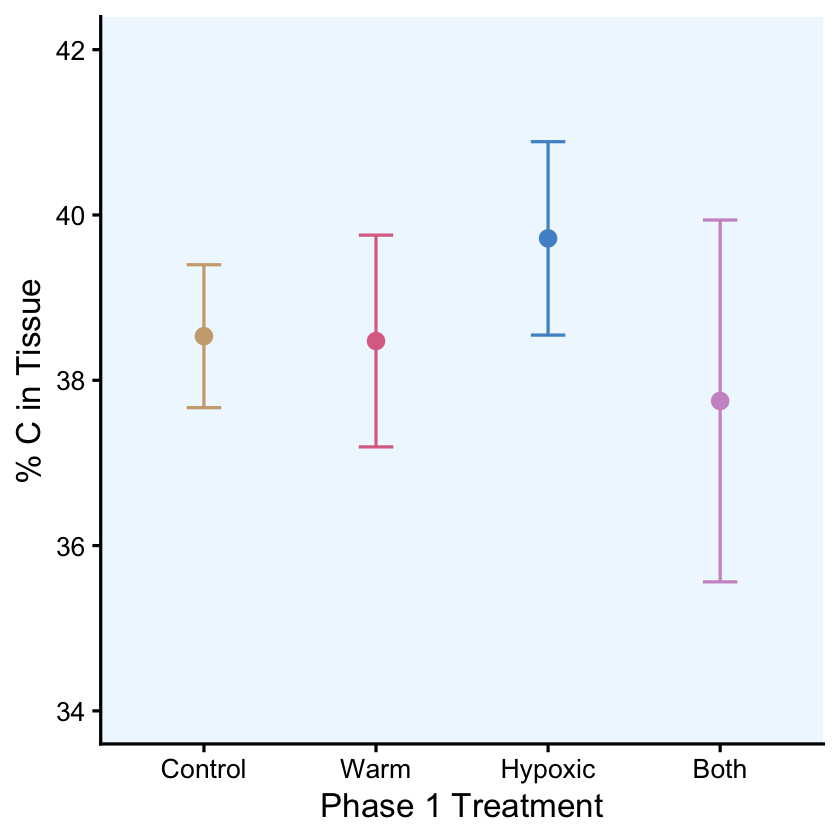

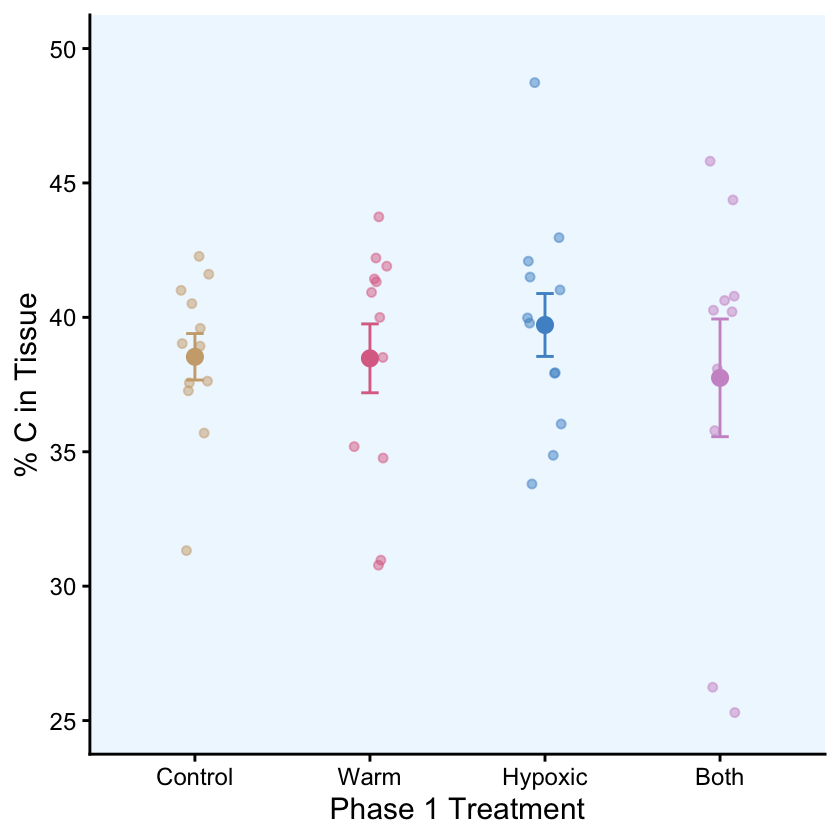

In [9]:
#summary stats
summary_stats <- C_T_df %>%
  group_by(Phase_1_treat) %>%
  summarize(
    mean_growth = mean(wt_percent_C, na.rm = TRUE),
    se_growth = std.error(wt_percent_C, na.rm = TRUE))

#reorder Phase_1_treat
summary_stats$Phase_1_treat <- factor(summary_stats$Phase_1_treat, 
                                      levels = c("Cont", "Warm","Hyp", "Both"))
#plot
ggplot(summary_stats, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 20) +
  theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light grey
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "% C in Tissue") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  ylim(34,42)+
  theme(legend.position = "none") # Remove legend
#plot with raw data
ggplot(summary_stats, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_jitter(data = C_T_df,
              aes(x = Phase_1_treat, y = wt_percent_C, color = Phase_1_treat),
              width = 0.1, alpha = 0.5, size = 2) +
  geom_point(size = 4, position = position_dodge(0.9)) +
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.1, position = position_dodge(0.9)) +
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) +
  guides(color = "none") +
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred",
                                "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "% C in Tissue") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control",
                              "Warm" = "Warm", "Both" = "Both")) +
ylim(25, 50)+
  theme(legend.position = "none")

### Analysis

In [10]:
Cm1 <- lmer(log(wt_percent_C) ~ Phase_1_DO*Phase_1_temp +
              (1|Phase_1_rep_R), data = C_T_df, REML=TRUE)
aov_tab <-Anova(Cm1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),3.519110e+04,1,19.72065,0.0000
Phase_1_DO,3.615743e-04,1,19.72065,0.9850
Phase_1_temp,7.808316e-01,1,19.72065,0.3875
Phase_1_DO:Phase_1_temp,5.671695e-01,1,19.72065,0.4603


#### No significant interactions

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,3,1.031584,0.388394
,42,NA,NA


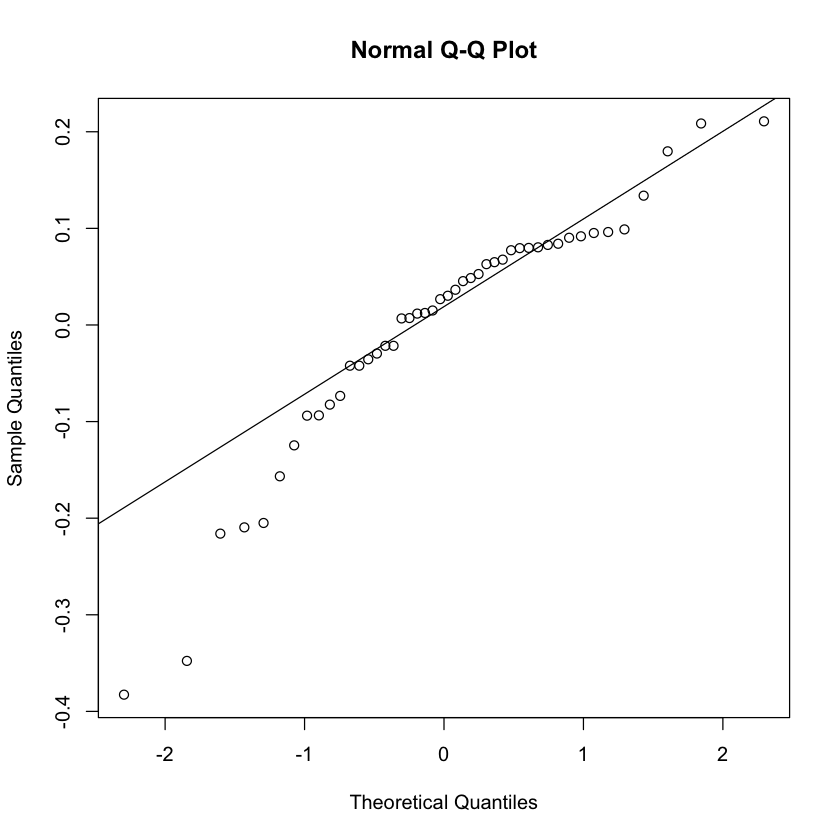

In [11]:
#diagnostics
leveneTest(log(wt_percent_C)~Phase_1_DO*Phase_1_temp, C_T_df)
m1.e <- residuals(Cm1) 
qqnorm(m1.e)
qqline(m1.e)

## Carbon:Nitrogen in Tissue

In [13]:
#read in data
Tissue_Nutrient_df <- read_csv("Phase1_tissuenutrient_working.csv", 
                               col_types = cols(wt_percent_N = col_number(), 
                                                wt_percent_C = col_number()))

#filter out exclusions for N and C
CN_T_df <- Tissue_Nutrient_df %>%
  filter( (is.na(N_exclude) | N_exclude != "Y") &
            (is.na(C_exclude) | C_exclude != "Y") )

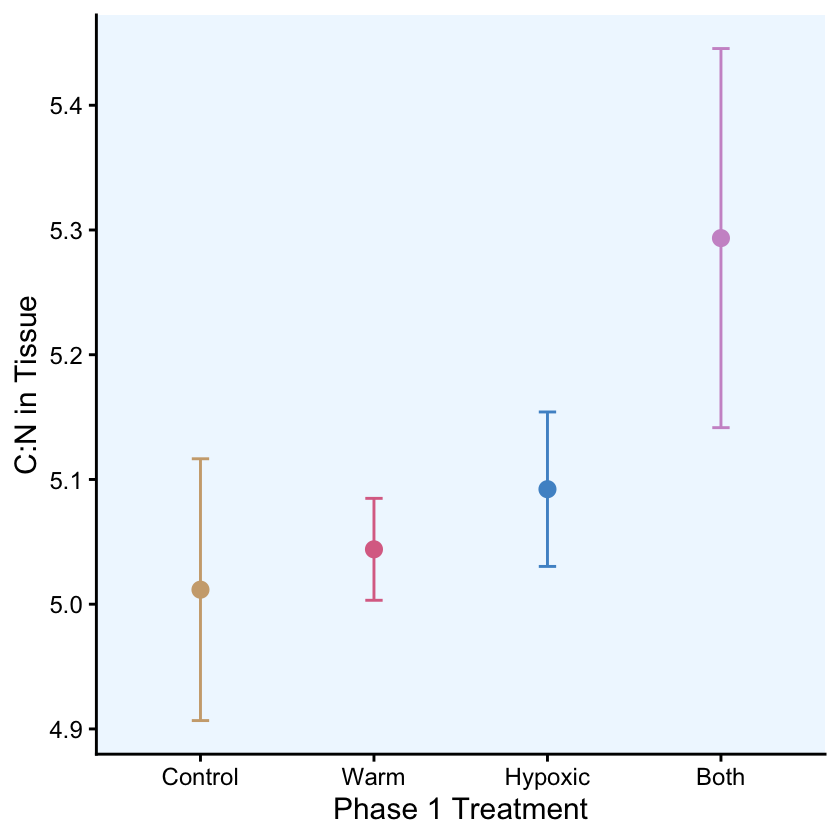

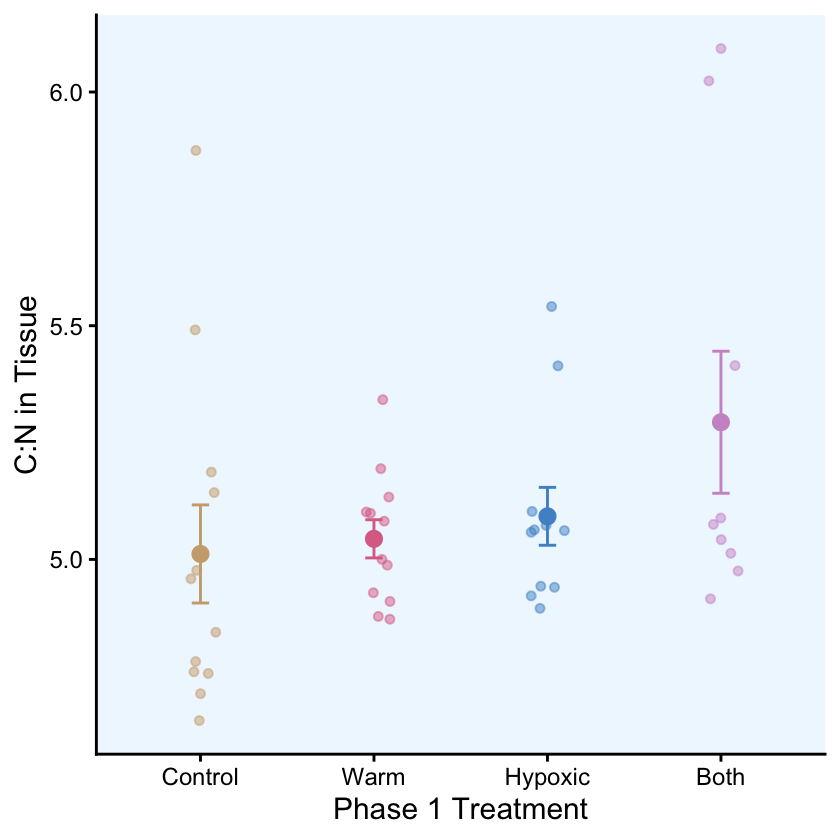

In [14]:
#summary stats
summary_stats <- CN_T_df %>%
  group_by(Phase_1_treat) %>%
  summarize(
    mean_growth = mean((wt_percent_C/wt_percent_N), na.rm = TRUE),
    se_growth = std.error((wt_percent_C/wt_percent_N), na.rm = TRUE))
#reorder Phase_1_treat
summary_stats$Phase_1_treat <- factor(summary_stats$Phase_1_treat, 
                                      levels = c("Cont", "Warm","Hyp", "Both"))
#plot
ggplot(summary_stats, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) +
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.1, position = position_dodge(0.9)) +
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) +
  guides(color = "none") +
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred",
                                "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "C:N in Tissue") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control",
                              "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none")

#plot with raw data
ggplot(summary_stats, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) +
  geom_jitter(data = CN_T_df,
              aes(x = Phase_1_treat, y = (wt_percent_C/wt_percent_N), color = Phase_1_treat),
              width = 0.1, alpha = 0.5, size = 2) +
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.1, position = position_dodge(0.9)) +
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) +
  guides(color = "none") +
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred",
                                "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "C:N in Tissue") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control",
                              "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none")


In [15]:
## C:N 
CNm1 <- lmer(log(wt_percent_C/wt_percent_N) ~ Phase_1_DO*Phase_1_temp + 
              (1|Phase_1_rep_R), data = CN_T_df, REML=TRUE)
aov_tab <- Anova(CNm1, test="F", type="III")
        #log transformed model is preferred as compared by AIC

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),3.443808e+04,1,19.57171,0.0000
Phase_1_DO,3.220187e+00,1,19.57171,0.0882
Phase_1_temp,1.621440e+00,1,19.57171,0.2178
Phase_1_DO:Phase_1_temp,6.350939e-01,1,19.57171,0.4351


In [19]:
#not running many interactions and also runs with bonferroni adjustment
emmeans(CNm1,specs = pairwise ~ Phase_1_DO, adjust = "none")
emmeans(CNm1,specs = pairwise ~ Phase_1_DO, adjust = "bonferroni")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_DO emmean     SE   df lower.CL upper.CL
 Hypoxic      1.65 0.0131 21.8     1.62     1.67
 Normoxic     1.61 0.0117 17.2     1.59     1.64

Results are averaged over the levels of: Phase_1_temp 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 
Confidence level used: 0.95 

$contrasts
 contrast           estimate     SE   df t.ratio p.value
 Hypoxic - Normoxic   0.0315 0.0176 19.6   1.794  0.0882

Results are averaged over the levels of: Phase_1_temp 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 


NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_DO emmean     SE   df lower.CL upper.CL
 Hypoxic      1.65 0.0131 21.8     1.62     1.67
 Normoxic     1.61 0.0117 17.2     1.59     1.64

Results are averaged over the levels of: Phase_1_temp 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 
Confidence level used: 0.95 

$contrasts
 contrast           estimate     SE   df t.ratio p.value
 Hypoxic - Normoxic   0.0315 0.0176 19.6   1.794  0.0882

Results are averaged over the levels of: Phase_1_temp 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 


### Plotting significant factor

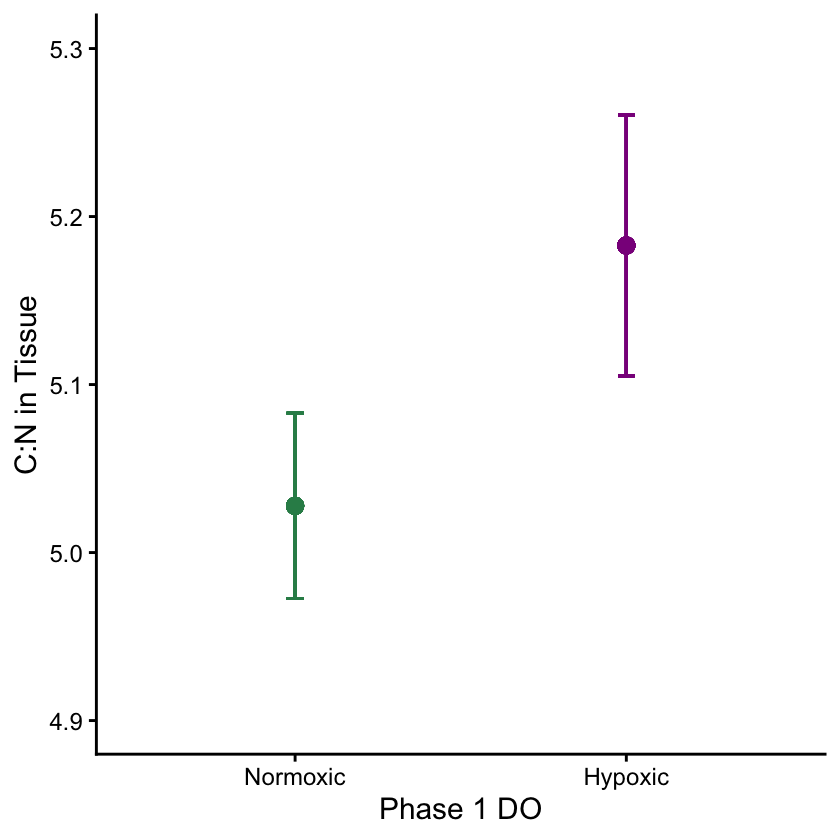

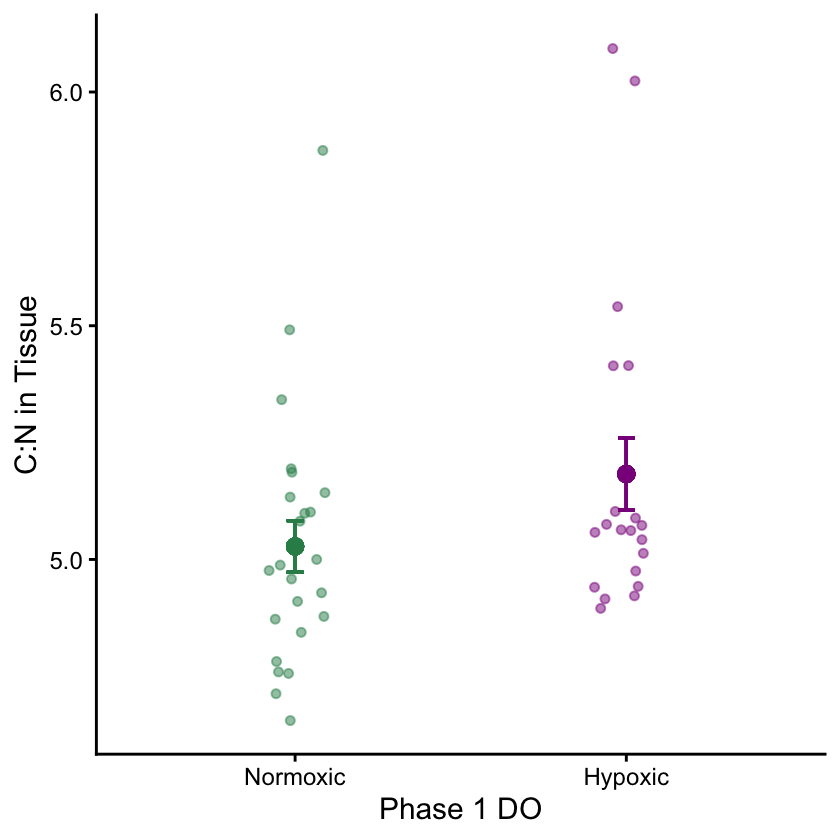

In [16]:
#summary stats
summary_stats <- CN_T_df %>%
  group_by(Phase_1_DO) %>%
  mutate(
    mean_cn = mean((wt_percent_C/wt_percent_N), na.rm = TRUE),
    se_cn = std.error((wt_percent_C/wt_percent_N), na.rm = TRUE))
#reorder
summary_stats$Phase_1_DO <- factor(summary_stats$Phase_1_DO, levels = c("Normoxic", "Hypoxic"))
#Tissue plot with mean and SD
ggplot(summary_stats, aes(x = Phase_1_DO, y = mean_cn, color = Phase_1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_cn - se_cn, ymax = mean_cn + se_cn), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hypoxic" = "darkmagenta", "Normoxic" = "seagreen")) +
  labs(x = "Phase 1 DO", y = "C:N in Tissue") +
ylim(4.9, 5.3)+
  theme(legend.position = "none") # Remove legend

#Tissue plot with mean and SD
ggplot(summary_stats, aes(x = Phase_1_DO, y = mean_cn, color = Phase_1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
geom_jitter(data = CN_T_df,
              aes(x = Phase_1_DO, y = (wt_percent_C/wt_percent_N), color = Phase_1_DO),
              width = 0.1, alpha = 0.5, size = 2) +
  geom_errorbar(aes(ymin = mean_cn - se_cn, ymax = mean_cn + se_cn), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hypoxic" = "darkmagenta", "Normoxic" = "seagreen")) +
  labs(x = "Phase 1 DO", y = "C:N in Tissue") +
  theme(legend.position = "none") # Remove legend

#### Oysters in hypoxia tended to store higher C:N than oysters in normoxia (p = 0.08)